# sampler_numpyro demo



This notebook shows a minimal NumPyro workflow built on `jeanspy.sampler_numpyro`.



It uses `storage_backend="zarr"` as the default because repeated NumPyro runs map naturally to chunked stores. If you prefer one file per chunk, the same API also supports `storage_backend="h5netcdf"` and `storage_backend="netcdf4"`.



It covers three steps:



1. Build a reusable Jeans likelihood with `JeansLikelihoodModel` and `ParameterSpec`.

2. Run one MCMC chunk and save both the NumPyro checkpoint and ArviZ outputs.

3. Start a fresh sampler instance, resume from the saved checkpoint, and combine the saved chunks back into one ArviZ `DataTree`.


In [1]:
from pathlib import Path
import shutil
import sys

def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Could not find repository root from current working directory")

repo_root = find_repo_root(Path.cwd().resolve())
src_dir = repo_root / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

repo_root

PosixPath('/home/gomesu/workspace/dev_jeanspy/jeanspy')

In [67]:
import importlib

import arviz as az
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS

import jeanspy.model_numpyro as model_numpyro_mod
import jeanspy.sampler_numpyro as sampler_numpyro_mod

importlib.reload(model_numpyro_mod)
importlib.reload(sampler_numpyro_mod)

from jeanspy.model_numpyro import (
    ConstantAnisotropyModel,
    DSphModel,
    NFWModel,
    PlummerModel,
)
from jeanspy.sampler_numpyro import JeansLikelihoodModel, NumPyroSampler, ParameterSpec

plt.style.use("default")

print("JAX backend:", jax.default_backend())

JAX backend: gpu


## Synthetic dataset

We generate a small mock data set so the notebook stays quick to run while still exercising the same APIs used in the larger demo notebook.

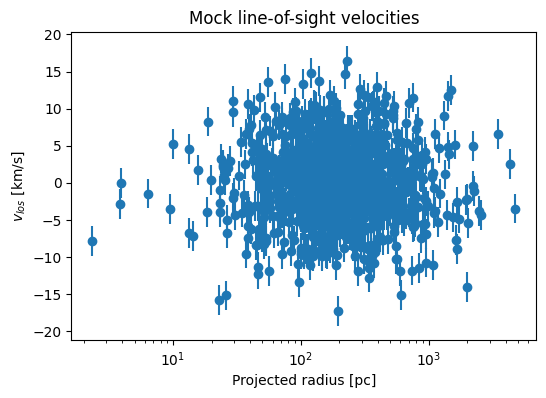

In [68]:
key = jax.random.PRNGKey(123)

num_samples = 1024

dsph = DSphModel(
    submodels={
        "StellarModel": PlummerModel(),
        "DMModel": NFWModel(),
        "AnisotropyModel": ConstantAnisotropyModel(),
    }
)

true_params = {
    "re_pc": 200.0,
    "rs_pc": 1200.0,
    "rhos_Msunpc3": 1e-2,
    "r_t_pc": 8000.0,
    "beta_ani": 0.2,
    "vmem_kms": 0.0,
}

key, radius_key = jax.random.split(key)
R_pc = dsph.submodels["StellarModel"].sample_R(radius_key, n=num_samples, re_pc=true_params["re_pc"])
e_vlos_kms = jnp.full_like(R_pc, 2.0)
sigma2_true = dsph.sigmalos2(
    R_pc,
    params=true_params,
    n_u=192,
    u_max=1500.0,
    constant_kernel_backend="jax",
)
key, noise_key = jax.random.split(key)
vlos_kms = true_params["vmem_kms"] + jnp.sqrt(sigma2_true + e_vlos_kms**2) * jax.random.normal(
    noise_key,
    shape=R_pc.shape,
)
vlos_min = jnp.min(vlos_kms)
vlos_max = jnp.max(vlos_kms)

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(np.asarray(R_pc), np.asarray(vlos_kms), yerr=np.asarray(e_vlos_kms), fmt="o")
ax.set_xscale("log")
ax.set_xlabel("Projected radius [pc]")
ax.set_ylabel("$v_{los}$ [km/s]")
ax.set_title("Mock line-of-sight velocities")
plt.show()

## Reusable likelihood definition

The notebook-level `jeans_model(...)` function becomes a reusable object here. Priors stay easy to adjust by editing the `parameter_specs` list.

In [69]:
beta_transform = lambda log10_1_minus_beta_ani: 1.0 - 10 ** log10_1_minus_beta_ani

def add_fixed_re_pc(params):
    re_pc = true_params["re_pc"]
    numpyro.deterministic("re_pc", re_pc)
    return {"re_pc": re_pc, **params}

parameter_specs = [
    ParameterSpec.pow10("log_rs", dist.Uniform(0.0, 5.0), param_name="rs_pc"),
    ParameterSpec.pow10("log_rhos", dist.Uniform(-5.0, 0.0), param_name="rhos_Msunpc3"),
    ParameterSpec.pow10("log_r_t", dist.Uniform(0.0, 5.0), param_name="r_t_pc"),
    ParameterSpec(
        "log10_1_minus_beta_ani",
        dist.Uniform(-1.0, 1.0),
        transform=beta_transform,
        param_name="beta_ani",
    ),
    ParameterSpec("vmem_kms", dist.Uniform(vlos_min, vlos_max)),
]

jeans_model = JeansLikelihoodModel(
    dsph_model=dsph,
    parameter_specs=parameter_specs,
    sigmalos2_kwargs={
        "n_u": 192,
        "u_max": 1500.0,
        "constant_kernel_backend": "jax",
    },
    parameter_postprocess=add_fixed_re_pc,
)

jeans_model

## Initial run with automatic checkpointing

`NumPyroSampler.run(...)` stores the latest NumPyro state in `last_state.pkl` and writes each ArviZ export as a chunk under the output directory.

In [73]:
output_dir = repo_root / "notebooks" / "_demo_outputs" / "sampler_numpyro_demo"

if output_dir.exists():
    shutil.rmtree(output_dir)

output_dir.mkdir(parents=True, exist_ok=True)

storage_backend = "zarr"

num_warmup = 400
num_samples = 1000
chain_method = "parallel" if jax.local_device_count() >= 2 else "sequential"

def build_mcmc():
    return MCMC(
        NUTS(
            jeans_model,
            dense_mass=True,
            max_tree_depth=10,
            target_accept_prob=0.8,
        ),
        num_warmup=num_warmup,
        num_samples=num_samples,
        num_chains=2,
        chain_method=chain_method,
        progress_bar=True,
        jit_model_args=True,
    )

first_sampler = NumPyroSampler(
    build_mcmc(),
    output_dir=output_dir,
    storage_backend=storage_backend,
    async_writes=True,
)

first_run = first_sampler.run(
    jax.random.PRNGKey(1),
    R_pc=R_pc,
    vlos_kms=vlos_kms,
    e_vlos_kms=e_vlos_kms,
)
first_sampler.flush()

print("storage backend:", storage_backend)
print("chain method:", chain_method)
print(first_run)
print("pending writes:", first_sampler.pending_write_count())
print("chunks after first run:", [path.name for path in first_sampler.list_chunk_paths()])

first_sampler.close()

sample: 100%|██████████| 1400/1400 [00:12<00:00, 109.26it/s, 7 steps of size 1.55e-01. acc. prob=0.79] 


storage backend: zarr
chain method: sequential
SamplerRunResult(resumed=False, checkpoint_path=PosixPath('/home/gomesu/workspace/dev_jeanspy/jeanspy/notebooks/_demo_outputs/sampler_numpyro_demo/last_state.pkl'), chunk_index=0, chunk_path=PosixPath('/home/gomesu/workspace/dev_jeanspy/jeanspy/notebooks/_demo_outputs/sampler_numpyro_demo/chunks/chunk_0000.zarr'), write_submitted=True)
pending writes: 0
chunks after first run: ['chunk_0000.zarr']


## Resume from disk in a fresh sampler instance

This simulates stopping the notebook kernel and continuing later. The new sampler loads the saved checkpoint, skips warmup, and appends a second ArviZ chunk.

In [74]:
resumed_sampler = NumPyroSampler(
    build_mcmc(),
    output_dir=output_dir,
    storage_backend=storage_backend,
    async_writes=False,
)

resumed_sampler.load_checkpoint()
second_run = resumed_sampler.run(
    jax.random.PRNGKey(2),
    R_pc=R_pc,
    vlos_kms=vlos_kms,
    e_vlos_kms=e_vlos_kms,
    resume=True,
)

print(second_run)
print("chunks after second run:", [path.name for path in resumed_sampler.list_chunk_paths()])

sample: 100%|██████████| 1000/1000 [00:07<00:00, 126.22it/s, 15 steps of size 1.55e-01. acc. prob=0.80]


SamplerRunResult(resumed=True, checkpoint_path=PosixPath('/home/gomesu/workspace/dev_jeanspy/jeanspy/notebooks/_demo_outputs/sampler_numpyro_demo/last_state.pkl'), chunk_index=1, chunk_path=PosixPath('/home/gomesu/workspace/dev_jeanspy/jeanspy/notebooks/_demo_outputs/sampler_numpyro_demo/chunks/chunk_0001.zarr'), write_submitted=False)
chunks after second run: ['chunk_0000.zarr', 'chunk_0001.zarr']


In [ ]:
# repeat several times to extend the same posterior while reusing the saved warmup state
for i in range(3, 6):
    resumed_sampler.load_checkpoint()
    run = resumed_sampler.run(
        jax.random.PRNGKey(i),
        R_pc=R_pc,
        vlos_kms=vlos_kms,
        e_vlos_kms=e_vlos_kms,
        resume=True,
    )
    print(run)
    print(f"chunks after run {i}:", [path.name for path in resumed_sampler.list_chunk_paths()])

  0%|          | 0/1000 [00:00<?, ?it/s]

sample: 100%|██████████| 1000/1000 [00:06<00:00, 148.25it/s, 15 steps of size 2.24e-01. acc. prob=0.92]


SamplerRunResult(resumed=True, checkpoint_path=PosixPath('/home/gomesu/workspace/dev_jeanspy/jeanspy/notebooks/_demo_outputs/sampler_numpyro_demo/last_state.pkl'), chunk_index=2, chunk_path=PosixPath('/home/gomesu/workspace/dev_jeanspy/jeanspy/notebooks/_demo_outputs/sampler_numpyro_demo/chunks/chunk_0002.zarr'), write_submitted=False)
chunks after run 3: ['chunk_0000.zarr', 'chunk_0001.zarr', 'chunk_0002.zarr']


sample: 100%|██████████| 1000/1000 [00:06<00:00, 146.58it/s, 15 steps of size 2.24e-01. acc. prob=0.92]


SamplerRunResult(resumed=True, checkpoint_path=PosixPath('/home/gomesu/workspace/dev_jeanspy/jeanspy/notebooks/_demo_outputs/sampler_numpyro_demo/last_state.pkl'), chunk_index=3, chunk_path=PosixPath('/home/gomesu/workspace/dev_jeanspy/jeanspy/notebooks/_demo_outputs/sampler_numpyro_demo/chunks/chunk_0003.zarr'), write_submitted=False)
chunks after run 4: ['chunk_0000.zarr', 'chunk_0001.zarr', 'chunk_0002.zarr', 'chunk_0003.zarr']


sample: 100%|██████████| 1000/1000 [00:06<00:00, 147.75it/s, 15 steps of size 2.24e-01. acc. prob=0.93]


SamplerRunResult(resumed=True, checkpoint_path=PosixPath('/home/gomesu/workspace/dev_jeanspy/jeanspy/notebooks/_demo_outputs/sampler_numpyro_demo/last_state.pkl'), chunk_index=4, chunk_path=PosixPath('/home/gomesu/workspace/dev_jeanspy/jeanspy/notebooks/_demo_outputs/sampler_numpyro_demo/chunks/chunk_0004.zarr'), write_submitted=False)
chunks after run 5: ['chunk_0000.zarr', 'chunk_0001.zarr', 'chunk_0002.zarr', 'chunk_0003.zarr', 'chunk_0004.zarr']


## Load the saved chunks back into ArviZ

`load_samples(combine=True)` concatenates `draw`-bearing groups such as `posterior` and reuses static groups such as `observed_data`.

In [76]:
var_names = ["log_rs", "log_rhos", "log_r_t", "beta_ani", "vmem_kms"]
idata = resumed_sampler.load_samples(combine=True)
summary = az.summary(
    idata,
    var_names=var_names,
    kind="diagnostics",
)
summary

,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
log_rs,577,493,1.00,0.0086,0.0065
log_rhos,579,521,1.00,0.011,0.0084
log_r_t,772,1008,1.00,0.019,0.0083
beta_ani,988,1037,1.00,0.0054,0.0041
vmem_kms,1589,2015,1.00,0.0041,0.003


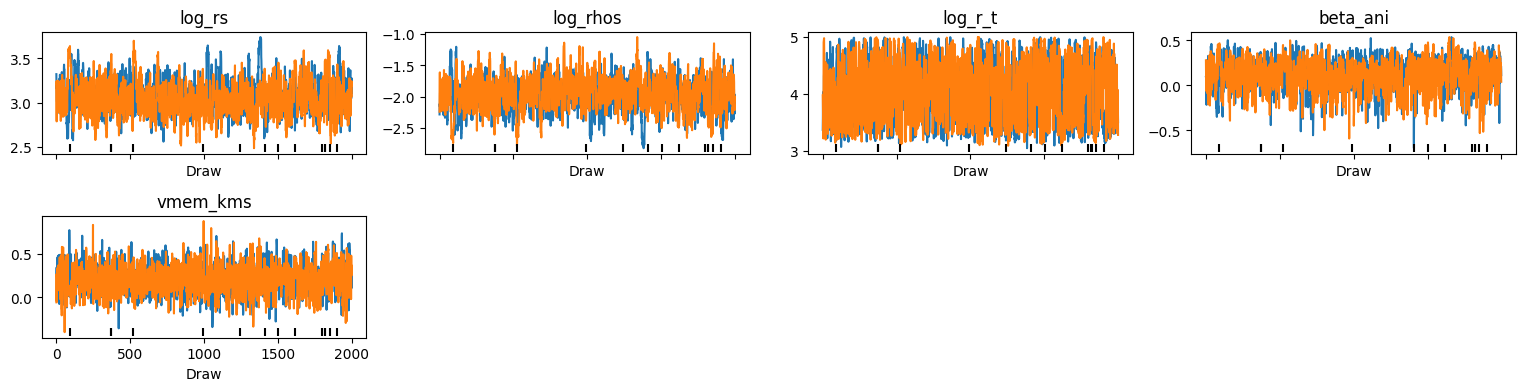

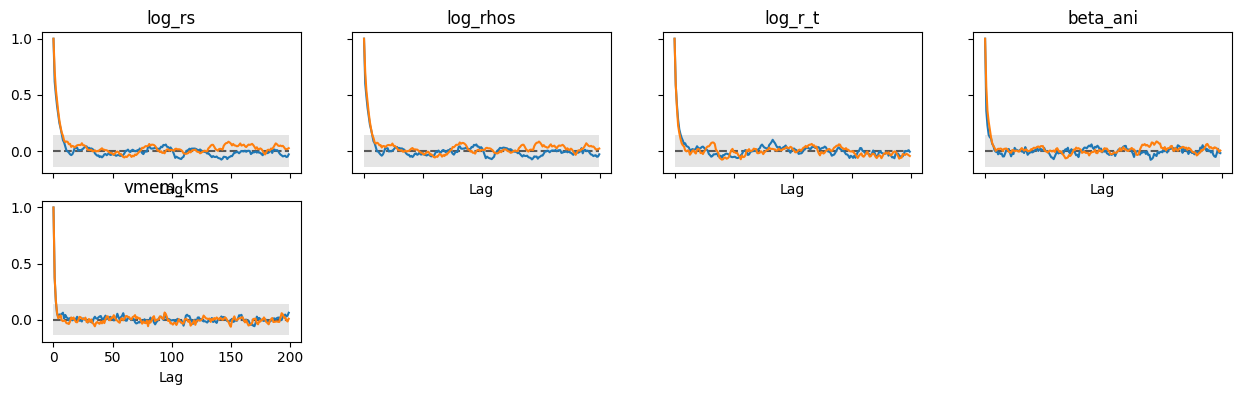

In [77]:
az.plot_trace(idata, var_names=var_names)
plt.tight_layout()
plt.show()

az.plot_autocorr(idata, var_names=var_names, max_lag=200)
plt.show()

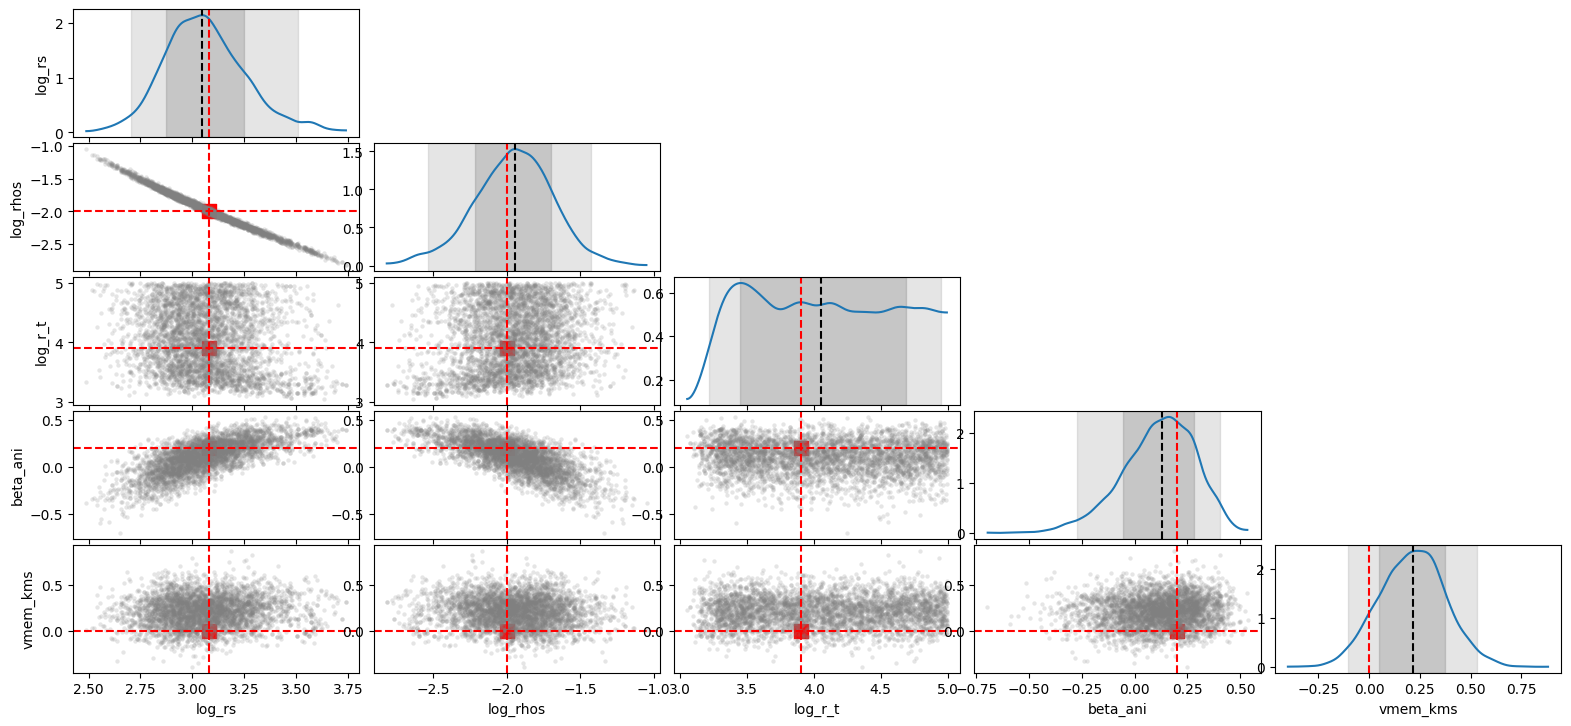

<xarray.DataTree>
Group: /
├── Group: /observed_data
│       Dimensions:     (vlos_dim_0: 1024)
│       Coordinates:
│         * vlos_dim_0  (vlos_dim_0) int64 8kB 0 1 2 3 4 5 ... 1019 1020 1021 1022 1023
│       Data variables:
│           vlos        (vlos_dim_0) float32 4kB -9.685 -2.726 -0.1755 ... -7.35 1.927
│       Attributes:
│           created_at:                 2026-03-11T06:33:45.810250+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.0.0
│           creation_library_language:  Python
│           inference_library:          numpyro
│           inference_library_version:  0.20.0
├── Group: /posterior
│       Dimensions:                 (chain: 2, draw: 2000)
│       Coordinates:
│         * chain                   (chain) int64 16B 0 1
│         * draw                    (draw) int64 16kB 0 1 2 3 4 ... 1996 1997 1998 1999
│       Data variables:
│           log_rhos                (chain, draw) float32 16kB -2.281 -2.112 ... -2.127
│           r_t_pc                  (chain, draw) float32 16kB 2.363e+03 ... 1.924e+03
│           rs_pc                   (chain, draw) float32 16kB 2.102e+03 ... 1.535e+03
│           log_r_t                 (chain, draw) float32 16kB 3.373 3.58 ... 3.284
│           vmem_kms                (chain, draw) float32 16kB 0.255 0.2436 ... 0.3519
│           log10_1_minus_beta_ani  (chain, draw) float32 16kB -0.04259 ... -0.01751
│           re_pc                   (chain, draw) float32 16kB 200.0 200.0 ... 200.0
│           beta_ani                (chain, draw) float32 16kB 0.09342 ... 0.03951
│           log_rs                  (chain, draw) float32 16kB 3.323 3.163 ... 3.186
│           rhos_Msunpc3            (chain, draw) float32 16kB 0.005234 ... 0.007467
│       Attributes:
│           created_at:                 2026-03-11T06:33:45.805544+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.0.0
│           creation_library_language:  Python
│           inference_library:          numpyro
│           inference_library_version:  0.20.0
└── Group: /sample_stats
        Dimensions:    (chain: 2, draw: 2000)
        Coordinates:
          * chain      (chain) int64 16B 0 1
          * draw       (draw) int64 16kB 0 1 2 3 4 5 6 ... 1994 1995 1996 1997 1998 1999
        Data variables:
            diverging  (chain, draw) bool 4kB False False False ... False False False
        Attributes:
            created_at:                 2026-03-11T06:33:45.809020+00:00
            creation_library:           ArviZ
            creation_library_version:   1.0.0
            creation_library_language:  Python
            inference_library:          numpyro
            inference_library_version:  0.20.0

In [78]:
# plot posterior structure with the same parameterization as jeanspy_numpyro_demo.ipynb

true_values = {
    "log_rs": jnp.log10(true_params["rs_pc"]),
    "log_rhos": jnp.log10(true_params["rhos_Msunpc3"]),
    "log_r_t": jnp.log10(true_params["r_t_pc"]),
    "beta_ani": true_params["beta_ani"],
    "vmem_kms": true_params["vmem_kms"],
}
plot_var_names = ["log_rs", "log_rhos", "log_r_t", "beta_ani", "vmem_kms"]

plot_matrix = az.plot_pair(
    idata,
    var_names=plot_var_names,
    marginal=True,
    marginal_kind="kde",
    triangle="lower",
    backend="matplotlib",
    visuals={
        "scatter": {"color": "gray", "alpha": 0.2, "s": 10},
        "dist": {"color": "C0"},
    },
)

figure = plot_matrix.iget_target(0, 0).figure
figure.subplots_adjust(wspace=0.05, hspace=0.05)

for i, var_i in enumerate(plot_var_names):
    true_i = true_values.get(var_i)
    for j, var_j in enumerate(plot_var_names):
        if j > i:
            continue

        ax = plot_matrix.iget_target(i, j)
        if i == j:
            if true_i is not None:
                ax.axvline(float(true_i), color="red", linestyle="--", label=f"true {var_i}")

            samples = np.asarray(idata.posterior[var_i].values).reshape(-1)
            ci_68 = np.percentile(samples, [16, 84])
            ci_95 = np.percentile(samples, [2.5, 97.5])
            ci_50 = float(np.percentile(samples, 50))
            ylim = ax.get_ylim()
            ax.fill_betweenx(y=ylim, x1=ci_68[0], x2=ci_68[1], color="gray", alpha=0.3, label="68% CI")
            ax.fill_betweenx(y=ylim, x1=ci_95[0], x2=ci_95[1], color="gray", alpha=0.2, label="95% CI")
            ax.axvline(ci_50, color="black", linestyle="--", label="median")
            ax.set_ylim(ylim)
            continue

        true_j = true_values.get(var_j)
        if true_i is not None:
            ax.axhline(float(true_i), color="red", linestyle="--")
        if true_j is not None:
            ax.axvline(float(true_j), color="red", linestyle="--")
        if true_i is not None and true_j is not None:
            ax.scatter(float(true_j), float(true_i), color="red", marker="s", s=100)

plt.show()
az.summary(idata, var_names=plot_var_names)
idata

## Saved file layout



With ArviZ 1.x and the optional I/O backends installed, each sampling chunk is stored as one backend-native `DataTree` store. In this demo we use `zarr`, so each chunk is a `.zarr` directory. If you switch to `h5netcdf` or `netcdf4`, each chunk becomes one `.nc` file instead.


In [62]:
print("top-level output files:")

for path in sorted(output_dir.iterdir()):

    marker = "/" if path.is_dir() else ""

    print(f"  {path.name}{marker}")



print("\nchunk stores:")

for path in resumed_sampler.list_chunk_paths():

    marker = "/" if path.is_dir() else ""

    print(f"  {path.name}{marker}")



resumed_sampler.close()


top-level output files:
  chunks/
  last_state.pkl
  metadata.json

chunk stores:
  chunk_0000.zarr/
  chunk_0001.zarr/
  chunk_0002.zarr/
  chunk_0003.zarr/
  chunk_0004.zarr/
